In [1]:
import os

from torch._C import dtype

os.chdir(r"C:\Users\affan\OneDrive\Desktop\Projects\Insurance_prediction")

import pandas as pd
import numpy as np


insu_df = pd.read_csv("dataset/raw_dataset/Dataset.csv")


In [3]:
# checking how many att val's have been missing

for att in insu_df:

    print(f"{att}:{insu_df[att].isnull().sum()}",end = "\n")
    

ID:0
ID_policy:0
ID_insured:0
period:0
date_effect_insured:0
date_lapse_insured:167181
date_effect_policy:0
date_lapse_policy:174568
year_effect_insured:0
year_lapse_insured:167181
year_effect_policy:0
year_lapse_policy:174568
exposure_time:0
lapse:0
seniority_insured:0
seniority_policy:0
type_policy:0
type_policy_dg:0
type_product:0
reimbursement:0
new_business:0
distribution_channel:0
gender:0
age:0
premium:0
cost_claims_year:0
n_medical_services:0
n_insured_pc:0
n_insured_mun:0
n_insured_prov:0
IICIMUN:10886
IICIPROV:5701
C_H:10886
C_GI:13213
C_II:13213
C_IE_P:13213
C_IE_S:13213
C_IE_T:13213
C_GE_P:13213
C_GE_S:13213
C_GE_T:13213
C_C:10556


In [4]:
insu_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228711 entries, 0 to 228710
Data columns (total 42 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    228711 non-null  object 
 1   ID_policy             228711 non-null  int64  
 2   ID_insured            228711 non-null  int64  
 3   period                228711 non-null  int64  
 4   date_effect_insured   228711 non-null  object 
 5   date_lapse_insured    61530 non-null   object 
 6   date_effect_policy    228711 non-null  object 
 7   date_lapse_policy     54143 non-null   object 
 8   year_effect_insured   228711 non-null  int64  
 9   year_lapse_insured    61530 non-null   float64
 10  year_effect_policy    228711 non-null  int64  
 11  year_lapse_policy     54143 non-null   float64
 12  exposure_time         228711 non-null  float64
 13  lapse                 228711 non-null  int64  
 14  seniority_insured     228711 non-null  int64  
 15  

<Axes: >

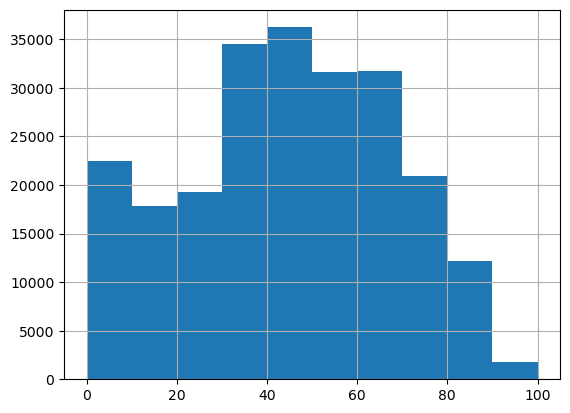

In [5]:
import numpy as np

bins = np.arange(0, insu_df["age"].max()+10 , 10)

insu_df["age"].hist(bins=bins)

In [6]:
df = insu_df

In [7]:
# we got all the non null value

for att in df:
    print(f"{att} : {(df[att].isnull().sum()/len(df[att]))*100}",end = "\n")

ID : 0.0
ID_policy : 0.0
ID_insured : 0.0
period : 0.0
date_effect_insured : 0.0
date_lapse_insured : 73.09705261224865
date_effect_policy : 0.0
date_lapse_policy : 76.32689289102842
year_effect_insured : 0.0
year_lapse_insured : 73.09705261224865
year_effect_policy : 0.0
year_lapse_policy : 76.32689289102842
exposure_time : 0.0
lapse : 0.0
seniority_insured : 0.0
seniority_policy : 0.0
type_policy : 0.0
type_policy_dg : 0.0
type_product : 0.0
reimbursement : 0.0
new_business : 0.0
distribution_channel : 0.0
gender : 0.0
age : 0.0
premium : 0.0
cost_claims_year : 0.0
n_medical_services : 0.0
n_insured_pc : 0.0
n_insured_mun : 0.0
n_insured_prov : 0.0
IICIMUN : 4.759718596831809
IICIPROV : 2.492665416180245
C_H : 4.759718596831809
C_GI : 5.777159821783823
C_II : 5.777159821783823
C_IE_P : 5.777159821783823
C_IE_S : 5.777159821783823
C_IE_T : 5.777159821783823
C_GE_P : 5.777159821783823
C_GE_S : 5.777159821783823
C_GE_T : 5.777159821783823
C_C : 4.615431702016956


                      null_count  null_rate
year_lapse_policy         174568  76.326893
date_lapse_policy         174568  76.326893
date_lapse_insured        167181  73.097053
year_lapse_insured        167181  73.097053
C_GE_T                     13213   5.777160
C_GE_S                     13213   5.777160
C_GE_P                     13213   5.777160
C_IE_T                     13213   5.777160
C_IE_S                     13213   5.777160
C_IE_P                     13213   5.777160
C_II                       13213   5.777160
C_GI                       13213   5.777160
C_H                        10886   4.759719
IICIMUN                    10886   4.759719
C_C                        10556   4.615432
IICIPROV                    5701   2.492665
age                            0   0.000000
n_insured_prov                 0   0.000000
n_insured_mun                  0   0.000000
n_insured_pc                   0   0.000000
n_medical_services             0   0.000000
cost_claims_year               0

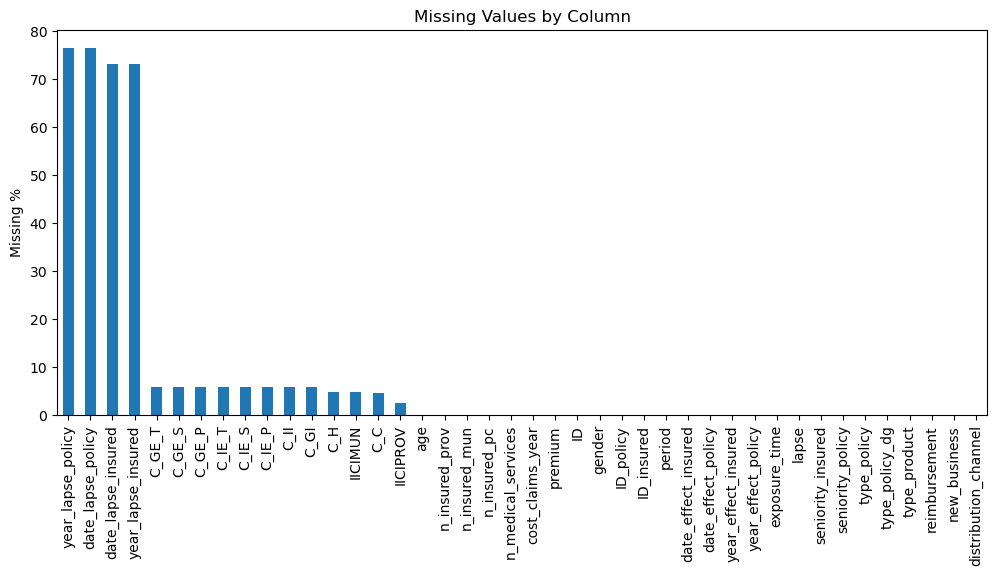

In [8]:

#this gives the details of how much data is missing

null_report = pd.DataFrame({
    "null_count": df.isna().sum(),
    "null_rate": df.isna().mean() * 100
})

null_report = null_report.sort_values(
    "null_rate",
    ascending=False
)

print(null_report)


import matplotlib.pyplot as plt

null_report["null_rate"].plot(kind="bar", figsize=(12,5))

plt.ylabel("Missing %")
plt.title("Missing Values by Column")
plt.show()

In [9]:
df['lapse'].value_counts(normalize=True)

lapse
2    0.818811
3    0.109711
1    0.071479
Name: proportion, dtype: float64

In [61]:
#getting the mean premium for the whole policy

insu_df["mean"] = insu_df.groupby(["ID_policy"])["premium"].transform("mean").sort_values()
insu_df[["ID_policy","mean"]].drop_duplicates()

,ID_policy,mean
0,1,2234.500325
2,2,2098.443333
3,3,1449.212850
7,4,2389.199333
8,5,1974.070533
...,...,...
228701,45158,522.972000
228702,45159,451.200118
228705,45160,581.748774
228706,45161,627.435000


In [20]:
insu_df.columns

Index(['ID', 'ID_policy', 'ID_insured', 'period', 'date_effect_insured',
       'date_lapse_insured', 'date_effect_policy', 'date_lapse_policy',
       'year_effect_insured', 'year_lapse_insured', 'year_effect_policy',
       'year_lapse_policy', 'exposure_time', 'lapse', 'seniority_insured',
       'seniority_policy', 'type_policy', 'type_policy_dg', 'type_product',
       'reimbursement', 'new_business', 'distribution_channel', 'gender',
       'age', 'premium', 'cost_claims_year', 'n_medical_services',
       'n_insured_pc', 'n_insured_mun', 'n_insured_prov', 'IICIMUN',
       'IICIPROV', 'C_H', 'C_GI', 'C_II', 'C_IE_P', 'C_IE_S', 'C_IE_T',
       'C_GE_P', 'C_GE_S', 'C_GE_T', 'C_C', 'dele'],
      dtype='str')

In [52]:
#just checking if the max of insured years is same or not

temp = pd.to_datetime(insu_df["date_effect_insured"],dayfirst=True)

diff = (
    temp.max()
    - temp.min()
)

diff.days/365

86.59726027397261

In [66]:
#this is to find how many people are categorized in a certain group

insu_df.groupby(by = ["lapse"])["ID"].nunique()

lapse
1    16348
2    80623
3    25092
Name: ID, dtype: int64